# Week 7 — Renewable / Net Demand

**Corrected framing** (PLAN.md): this was originally planned as `net_demand = demand - wind - solar`, which is wrong for this dataset — `wind`/`solar` are *embedded* generation, already invisibly netted into `demand` (`ND`) by physics before NESO ever measures it. Subtracting them again double-counts the same effect. Instead: treat high embedded-renewable output as **extra variance already sitting inside `demand` itself**, and ask whether forecast error concentrates there.

**Hypothesis**: Week 6's `is_high_wind` bucket already showed elevated bias (-796 MW) and degraded calibration (PICP 0.609 vs. 0.652 overall) using wind alone. Combining wind *and* solar, and looking at the *entire* range (deciles, not just top/bottom 10%) rather than an extremes-only flag, should show whether this is a sharp cliff at the very extreme or a smooth trend across the whole spectrum.

**Models used**: the decisions from the Week 6 follow-up — the point model uses the bias-corrected recipe (`is_christmas` feature + 3x sample weighting on `is_hot`/`is_high_wind`/`is_christmas`), the quantile model uses the untouched Week 5 baseline (that recipe was found to worsen PICP, so it was never adopted for probabilistic forecasting).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.baselines import previous_week_same_time
from edf.buckets import build_day_type_buckets, is_christmas_period, percentile_bin_buckets
from edf.evaluate import evaluate_by_bucket, evaluate_quantiles_by_bucket
from edf.features import build_feature_table
from edf.forecast import train_lightgbm
from edf.generation_features import capacity_factor
from edf.quantile import enforce_monotonic_quantiles
from edf.weather_features import build_weather_feature_table

pd.options.display.float_format = "{:.2f}".format
WEATHER_RAW_DIR = Path("../data/raw/weather")
HORIZON_PERIODS = config.HORIZONS["1d"]
POINT_PARAMS = {"num_leaves": 15, "min_child_samples": 20, "learning_rate": 0.05}
POINT_N_ESTIMATORS = 689
QUANTILE_PARAMS = {"num_leaves": 15, "min_child_samples": 50, "learning_rate": 0.1}
QUANTILE_N_ESTIMATORS = 549
UPWEIGHT = 3.0

In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
demand = df["demand"]
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION

era5 = build_weather_feature_table("open_meteo_historical", df.index, raw_dir=WEATHER_RAW_DIR)

## Rebuild the two "current" models (established hyperparameters, no re-tuning)

In [3]:
# point model: bias-corrected recipe (Week 6 follow-up's kept decision)
wind_cf_full = capacity_factor(df["wind"], df["wind_capacity"])
day_buckets_full = build_day_type_buckets(era5["temperature_c"], wind_cf_full)
problem_mask = day_buckets_full["is_hot"] | day_buckets_full["is_high_wind"] | day_buckets_full["is_christmas"]
weight_full = pd.Series(1.0, index=df.index)
weight_full[problem_mask] = UPWEIGHT

era5_chr = era5.copy()
era5_chr["is_christmas"] = is_christmas_period(df.index)
X_point, y = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=era5_chr)
X_train_point, y_train = X_point.loc[train_start:train_end], y.loc[train_start:train_end]
X_val_point, y_val = X_point.loc[val_start:val_end], y.loc[val_start:val_end]
weight_train = weight_full.loc[X_train_point.index]

point_model = train_lightgbm(
    X_train_point, y_train, sample_weight=weight_train, n_estimators=POINT_N_ESTIMATORS, **POINT_PARAMS
)
point_preds = pd.Series(point_model.predict(X_val_point), index=X_val_point.index)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002066 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5693
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 27001.358990


In [4]:
# quantile model: untouched Week 5 baseline (the kept decision for probabilistic forecasting)
X_q, y_q = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=era5)
X_train_q, y_train_q = X_q.loc[train_start:train_end], y_q.loc[train_start:train_end]
X_val_q = X_q.loc[val_start:val_end]

quantile_preds = {}
for alpha in [0.1, 0.5, 0.9]:
    m = train_lightgbm(
        X_train_q, y_train_q, objective="quantile", alpha=alpha, n_estimators=QUANTILE_N_ESTIMATORS, **QUANTILE_PARAMS
    )
    quantile_preds[alpha] = pd.Series(m.predict(X_val_q), index=X_val_q.index)
quantile_preds = enforce_monotonic_quantiles(quantile_preds)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 19322.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001025 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 26196.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001006 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 36093.000000


## Bucket by combined embedded renewable output (`wind + solar`), deciles

Computed over the full 2020-2025 range for stable thresholds, applied to `VALIDATION` rows — same convention as Week 6's day-type buckets.

In [5]:
renewable_full = df["wind"] + df["solar"]
renewable_buckets_full = percentile_bin_buckets(renewable_full, n_bins=10, prefix="renewable")
renewable_buckets_val = renewable_buckets_full.loc[val_start:val_end]
renewable_buckets_val.sum().rename("n_half_hours")

renewable_q1     1748
renewable_q2     1806
renewable_q3     1733
renewable_q4     1746
renewable_q5     1613
renewable_q6     1776
renewable_q7     1692
renewable_q8     1688
renewable_q9     1858
renewable_q10    1908
Name: n_half_hours, dtype: int64

## Point-model accuracy by renewable decile (q1 = lowest embedded wind+solar, q10 = highest)

In [6]:
naive_val = previous_week_same_time(demand).loc[val_start:val_end]
point_table = evaluate_by_bucket(y_val, point_preds, renewable_buckets_val, seasonal_naive_pred=naive_val)
point_table[["mae", "mase", "bias", "n"]]

,mae,mase,bias,n
all,885.70,0.44,-137.78,17568.00
renewable_q1,558.21,0.34,294.30,1748.00
renewable_q2,580.04,0.38,198.60,1806.00
renewable_q3,649.64,0.40,153.15,1733.00
renewable_q4,784.35,0.42,33.04,1746.00
renewable_q5,880.96,0.48,47.58,1613.00
renewable_q6,856.65,0.42,-148.65,1776.00
renewable_q7,920.90,0.43,-166.99,1692.00
renewable_q8,1028.93,0.40,-188.15,1688.00
renewable_q9,1130.13,0.47,-415.58,1858.00


## Finding: point accuracy degrades smoothly and substantially across the *entire* range

MAE climbs almost monotonically from 558 MW (decile 1, lowest wind+solar) to 1417 MW (decile 10) — **2.5x worse** at the high end than the low end. Bias tells the mechanism: it crosses zero smoothly around decile 4-5 and moves from strongly positive (+294 MW, under-forecasting when renewable output is low) to strongly negative (-1078 MW, over-forecasting when it's high) — a clean, physically coherent gradient, not a step change at some threshold. This is a sharper, more complete version of Week 6's `is_high_wind` finding (bias -796 MW): combining wind *and* solar, and looking across the whole spectrum rather than just the top/bottom 10%, shows the degradation isn't confined to extreme days — it's a **continuous trend spanning the entire distribution** of embedded renewable output. Every decile step up in renewable output costs measurable accuracy.

## Probabilistic-model calibration by renewable decile

In [7]:
prob_table = evaluate_quantiles_by_bucket(y_val, quantile_preds, renewable_buckets_val)
prob_table

,pinball_0.1,pinball_0.5,pinball_0.9,picp,n
all,239.77,447.38,200.30,0.65,17568.00
renewable_q1,118.33,275.86,129.11,0.70,1748.00
renewable_q2,126.09,291.03,148.67,0.70,1806.00
renewable_q3,143.88,331.11,161.01,0.72,1733.00
renewable_q4,194.70,378.53,177.74,0.67,1746.00
renewable_q5,221.08,438.00,222.50,0.60,1613.00
renewable_q6,213.01,432.37,207.41,0.68,1776.00
renewable_q7,242.39,467.44,213.34,0.66,1692.00
renewable_q8,283.17,524.64,236.37,0.63,1688.00
renewable_q9,326.13,583.19,239.02,0.64,1858.00


## Finding: PICP behaves differently — flat until the very top decile, then a cliff

Unlike MAE/bias, PICP does *not* trend smoothly across the whole range: deciles 1-9 sit in a fairly stable, noisy band (0.60-0.72), with no clear monotonic pattern — then decile 10 drops sharply to **0.52**, a fall of ~0.12-0.20 from every decile below it. This is a genuinely different shape from the point-model result, and worth being precise about rather than collapsing into "accuracy and calibration both get worse together":

- **Point accuracy degrades gradually and predictably** as embedded renewable share rises — useful operationally, since it means the accuracy cost of a high-renewable day is roughly proportional to how extreme it is, not an unpredictable cliff.
- **Calibration failure is concentrated almost entirely in the most extreme decile** — the top ~10% of embedded-renewable half-hours specifically, not a general trend across above-average renewable output. A demand forecast issued on a moderately-high-renewable day (deciles 6-9) has roughly the same (already-below-nominal) calibration as an average day; it's only the genuinely extreme tail where things fall apart further.

## Plot: MAE, bias, and PICP vs. renewable decile

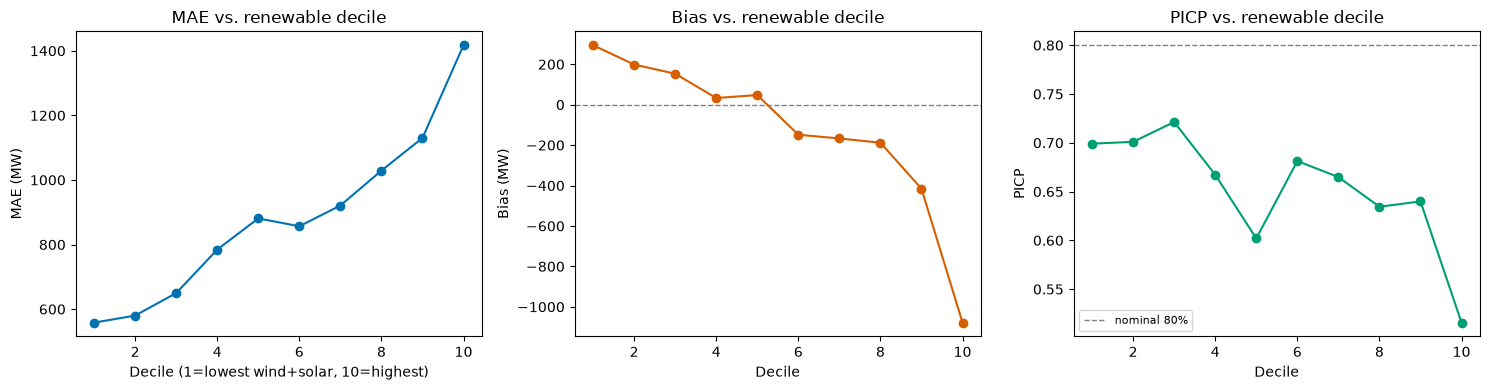

In [8]:
deciles = [f"renewable_q{i}" for i in range(1, 11)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(range(1, 11), point_table.loc[deciles, "mae"], marker="o", color="#0072B2")
axes[0].set_title("MAE vs. renewable decile")
axes[0].set_xlabel("Decile (1=lowest wind+solar, 10=highest)")
axes[0].set_ylabel("MAE (MW)")

axes[1].plot(range(1, 11), point_table.loc[deciles, "bias"], marker="o", color="#D55E00")
axes[1].axhline(0, color="grey", linestyle="--", linewidth=1)
axes[1].set_title("Bias vs. renewable decile")
axes[1].set_xlabel("Decile")
axes[1].set_ylabel("Bias (MW)")

axes[2].plot(range(1, 11), prob_table.loc[deciles, "picp"], marker="o", color="#009E73")
axes[2].axhline(0.8, color="grey", linestyle="--", linewidth=1, label="nominal 80%")
axes[2].set_title("PICP vs. renewable decile")
axes[2].set_xlabel("Decile")
axes[2].set_ylabel("PICP")
axes[2].legend(fontsize=8)

fig.tight_layout()

## Synthesis

**Answers PLAN.md's Week 7 question directly**: yes, the model is measurably less accurate *and* less calibrated during high-embedded-renewable periods — but not in the same shape. Accuracy cost scales continuously with renewable share; calibration cost is a tail phenomenon concentrated in roughly the top decile. Both point back to the same root cause already identified in Weeks 4/6/6-follow-up: embedded wind/solar suppress demand by physics before it's ever measured, the model's weather features only partially proxy for that effect (Week 4), and Week 4b already found that a dedicated wind/solar forecast can't close the gap either (self-forecasted generation recovered ~0% of the theoretical fix). **No new fix attempted here** — this notebook's job was to characterize *where and how* the problem shows up, not to solve it again; the honest state, matching Week 6's follow-up conclusion, is that point-side bias has a workable (if partial) fix, while the calibration problem specifically still needs a structurally different approach (the conformal-prediction / distributional-model stretch goal) to close.